In [1]:
import torch

### set up CUDA as device if available
if torch.cuda.is_available():
    print("GPU is available")
    device = torch.device("cuda")
    cuda_id = torch.cuda.current_device()
    print(f"ID of current CUDA device:{torch.cuda.current_device()}")
    print(f"Name of current CUDA device:{torch.cuda.get_device_name(cuda_id)}")
    print(f"CUDA version: {torch.version.cuda}")
else:
    print("GPU is not available, using CPU")
    device = torch.device("cpu")
print(f"device: {device}")

GPU is available
cuda
CUDA version: 12.4
ID of current CUDA device:0
Name of current CUDA device:NVIDIA H200


In [2]:
import numpy as np
import random
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, RobustScaler
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from tqdm import tqdm, trange
from sklearn.metrics import average_precision_score
from conf_and_plot import confusion_matrix_plots
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import torch.nn.functional as F

def seed_all(seed):
    if not seed:
        seed = 10

    print("[ Using Seed : ", seed, " ]")

    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.cuda.manual_seed(seed)
    np.random.seed(seed)
    random.seed(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

def seed_worker(worker_id):
    worker_seed = torch.initial_seed() % 2**32
    np.random.seed(worker_seed)
    random.seed(worker_seed)

seed_all(2025)

[ Using Seed :  2025  ]


In [3]:
scint_thresh = 0.1 # set the phase scintillation threshold

### following variable not being used anywhere
scint_outlier_thresh = 5. # set the value that determines phase scintillation outliers (these data samples will be removed)

processed_data_2015 = pd.read_csv("processed_data_2015.csv")
processed_data_2015 = processed_data_2015.drop(processed_data_2015.columns[0], axis=1)
predicted_label = 'sigmaPhi projected to vertical at prediction time [radians]'
y = processed_data_2015[predicted_label].values
print(y.shape)

X_fSelect = processed_data_2015.drop(predicted_label, axis=1)
X_fSelect = X_fSelect.values
print(X_fSelect.shape)

(4465846,)
(4465846, 15)


In [4]:
### tss model 2-12 cos iter 2
params = {'hidden_layer_size': 2, 
          'num_layers': 1, 
          'sequence_length': 35, 
          'dropout_p': 0.1, 
          'batch_size': 256, 
          'lr': 0.01, 
          'optimizer_type': 'adam', 
          'weight_decay': 0.05, 
          'loss': 'bce', 
          'bce_pos_class_weight': 60, 
          'input_layer_norm': False, 
          'num_epochs': 300, 
          'scheduler_t': 335, 
          'scheduler_type': 'cos'}

hidden_size=2
stacked_layers=1
seq_length = 35
dropout_param= 0.1
batch_size= 256
learning_rate = 0.01
opt = 'adam'  # 'sgd' or 'adam'
optim_weight_decay = 0.05  # adam and sgd
loss_select = 'bce'
positive_class_weight = 60
sgd_momentum = 0.9  # sgd

num_epochs = 300
scheduler_type = 'cos'  # None, 'plat', or 'cos'
scheduler_t = 335  # for 'cos'
metric = 'tss' # metric for 'plat' scheduler : 'tss' or 'hss'

output_features=1
input_features=15
training_data_size = 50000
test_data_size = 4365846


# final train tss = 0.7293 : final val tss = 0.6572
# final train hss = 0.2091 : final val hss = 0.2899
# test_TSS_2016: 0.5257
# test_HSS_2016: 0.1606
# AUC-ROC: 0.83
# Precision-Recall AUC: 0.17


In [5]:
### hss model 14-4 plat
params = {'hidden_layer_size': 2, 
          'num_layers': 1, 
          'sequence_length': 45, 
          'dropout_p': 0.1, 
          'batch_size': 256, 
          'lr': 0.025, 
          'optimizer_type': 'adam', 
          'weight_decay': 0.075, 
          'loss': 'bce', 
          'bce_pos_class_weight': 15, 
          'input_layer_norm': False, 
          'num_epochs': 300, 
          'scheduler_type': 'plat'}

hidden_size= 2
stacked_layers= 1
seq_length = 45
dropout_param= 0.1
batch_size= 256
learning_rate = 0.025
opt = 'adam'  # 'sgd' or 'adam'
optim_weight_decay = 0.075  # adam and sgd
loss_select = 'bce'
positive_class_weight = 15
sgd_momentum = 0.9  # sgd

num_epochs = 300
scheduler_type = 'plat'  # None, 'plat', or 'cos'
scheduler_t = 14  # for 'cos'
metric = 'hss' # metric for 'plat' scheduler : 'tss' or 'hss'

output_features=1
input_features=15
training_data_size = 50000
test_data_size = 4365846


# final train tss = 0.7257 : final val tss = 0.5495
# final train hss = 0.4208 : final val hss = 0.4086
# test_TSS_2016: 0.3341
# test_HSS_2016: 0.2043
# AUC-ROC: 0.79
# Precision-Recall AUC: 0.17


In [6]:
### tss+hss model 13-1 cos
params = {'hidden_layer_size': 24, 
          'num_layers': 1, 
          'sequence_length': 45, 
          'dropout_p': 0.2, 
          'batch_size': 256, 
          'lr': 0.005, 
          'optimizer_type': 'adam', 
          'weight_decay': 0.05, 
          'loss': 'bce', 
          'bce_pos_class_weight': 30, 
          'input_layer_norm': False, 
          'num_epochs': 100, 
          'scheduler_t': 14, 
          'scheduler_type': 'cos'}

hidden_size= 24
stacked_layers= 1
seq_length = 45
dropout_param= 0.2
batch_size= 256
learning_rate = 0.005
opt = 'adam'  # 'sgd' or 'adam'
optim_weight_decay = 0.05  # adam and sgd
loss_select = 'bce'
positive_class_weight = 30
sgd_momentum = 0.9  # sgd

num_epochs = 100
scheduler_type = 'cos'  # None, 'plat', or 'cos'
scheduler_t = 14  # for 'cos'
metric = 'hss' # metric for 'plat' scheduler : 'tss' or 'hss'

output_features=1
input_features=15
training_data_size = 50000
test_data_size = 4365846


# final train tss = 0.7651 : final val tss = 0.6628
# final train hss = 0.3548 : final val hss = 0.3737
# test_TSS_2016: 0.4645
# test_HSS_2016: 0.1950
# 0.6595
# AUC-ROC: 0.85
# Precision-Recall AUC: 0.18


In [7]:
# Convert y to binary values (1=scintillation; 0=no-scintillation)
y[y>scint_thresh] = 1
y[y<=scint_thresh] = 0

X_train, X_test, \
    y_train, y_test, \
        idx_train, idx_test = train_test_split(X_fSelect, y, range(len(y)), train_size=training_data_size, shuffle=False)
X_val, X_test, \
    y_val, y_test, \
        idx_val, idx_test = train_test_split(X_test, y_test, range(len(y_test)), test_size=test_data_size, shuffle=False)

# Create input data scaler based only on training set
scaler_X = RobustScaler()
scaler_X = scaler_X.fit(X_train)

X_train_scaled = scaler_X.transform(X_train)
X_val_scaled = scaler_X.transform(X_val)
X_test_scaled = scaler_X.transform(X_test)

def reshape_data_to_seq_length(data, seq_len):
    num_samples = data.shape[0]
    input_features = data.shape[1]
    num_batches = num_samples // seq_len
    data = data[:num_batches * seq_len]
    reshaped_data = data.reshape(num_batches, seq_len, input_features)
    return reshaped_data

def reshape_labels_to_seq_length(labels, seq_len):
    labels = torch.from_numpy(labels) if isinstance(labels, np.ndarray) else labels
    num_samples = labels.shape[0]
    num_batches = num_samples // seq_len
    labels = labels[:num_batches * seq_len]
    labels = labels.view(num_batches, seq_len, -1)
    return labels

X_train_scaled = reshape_data_to_seq_length(X_train_scaled, seq_length)
X_val_scaled = reshape_data_to_seq_length(X_val_scaled, seq_length)
X_test_scaled = reshape_data_to_seq_length(X_test_scaled, seq_length)

train_labels = reshape_labels_to_seq_length(y_train, seq_length)
val_labels = reshape_labels_to_seq_length(y_val, seq_length)
test_labels = reshape_labels_to_seq_length(y_test, seq_length)

train_data = torch.tensor(X_train_scaled, dtype=torch.float32)
train_data = train_data.to(device)
train_labels = train_labels.to(device)
dataset = TensorDataset(train_data, train_labels)
dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=False, worker_init_fn=seed_worker)

val_data = torch.tensor(X_val_scaled, dtype=torch.float32)
val_data = val_data.to(device)
val_labels = val_labels.to(device)
val_dataset = TensorDataset(val_data, val_labels)
val_dataloader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, worker_init_fn=seed_worker)

test_data = torch.tensor(X_test_scaled, dtype=torch.float32)
test_data = test_data.to(device)
test_labels = test_labels.to(device)
test_dataset = TensorDataset(test_data, test_labels)
test_dataloader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, worker_init_fn=seed_worker)

In [8]:
def true_skill_score(y_true, y_pred):
    TP = np.sum((y_true == 1) & (y_pred == 1))
    TN = np.sum((y_true == 0) & (y_pred == 0))
    FP = np.sum((y_true == 0) & (y_pred == 1))
    FN = np.sum((y_true == 1) & (y_pred == 0))
    tss = (TP / (TP + FN)) - (FP / (FP + TN))
    return tss

def heidke_skill_score(y_true, y_pred):
    TP = np.sum((y_true == 1) & (y_pred == 1))
    TN = np.sum((y_true == 0) & (y_pred == 0))
    FP = np.sum((y_true == 0) & (y_pred == 1))
    FN = np.sum((y_true == 1) & (y_pred == 0))
    
    numerator = 2 * (TP * TN - FP * FN)
    denominator = (TP + FP) * (FP + TN) + (TP + FN) * (TN + FP)
    
    # Avoid division by zero
    if denominator == 0:
        return 0.0
    
    hss = numerator / denominator
    return hss

In [9]:
class LSTM_model(nn.Module):
    # def __init__(self, input_size=1, hidden_layer_size=hidden_size, num_layers=stacked_layers, num_classes=output_features):
    def __init__(self, input_size=input_features, hidden_layer_size=hidden_size, num_layers=stacked_layers, num_classes=output_features):
        super(LSTM_model, self).__init__()
        
        self.lstm = nn.LSTM(input_size, hidden_layer_size, num_layers, batch_first=True)
        self.dropout = nn.Dropout(dropout_param)
        self.fc = nn.Linear(hidden_layer_size, num_classes)
        self.sigmoid = nn.Sigmoid()

        self.layer_norm_input = nn.LayerNorm(input_size)
        self.layer_norm_output = nn.LayerNorm(hidden_layer_size)

    def forward(self, x):

        # x = self.layer_norm_input(x)
        lstm_out, _ = self.lstm(x)

        # # Use the last hidden state (last timestep) for classification
        # final_hidden_state = lstm_out[:, -1, :]  
        # final_hidden_state = self.dropout(final_hidden_state)
        # output = self.fc(final_hidden_state)

        # lstm_out = self.layer_norm_output(lstm_out)
        lstm_out = self.dropout(lstm_out)
        output = self.fc(lstm_out)
        
        # if loss_select == 'focal':
        #     output = self.sigmoid(output)
        # elif loss_select == 'bce':
        #     pass
        return output

In [10]:
def plot_training_validation_curves(training_hss, validation_hss, training_tss, validation_tss, training_loss, validation_loss, epochs):
    
    lw = 0.8
    ms = 2
    ls = (0, (5, 10)) # loosely dashed
    ls = (0, (1, 5)) # dotted
    ls = (0, (1, 2)) # densely dotted
    
    # Create the figure and the first set of axes
    fig, ax1 = plt.subplots()
    
    ax1.plot(range(epochs), training_loss, color='b', linewidth=lw, label='training loss')
    ax1.plot(range(epochs), validation_loss, color='b', linewidth=lw, linestyle=ls, label='validation loss')
    ax1.set_xlabel('epochs')
    ax1.set_ylabel('loss', color='b')
    ax1.tick_params('y', colors='b')

    # Create a second set of axes sharing the same x-axis
    ax2 = ax1.twinx()

    ax2.plot(range(epochs), training_tss, color='r', linewidth=lw, label='training TSS')
    ax2.plot(range(epochs), validation_tss, color='r', linewidth=lw, linestyle=ls, label='validation TSS')

    ax2.plot(range(epochs), training_hss, color='orange', linewidth=lw, label='training HSS')
    ax2.plot(range(epochs), validation_hss, color='orange', linewidth=lw, linestyle=ls, label='validation TSS')
    ax2.set_ylabel('TSS/HSS', color='r')
    ax2.tick_params('y', colors='r')

    plt.title(f'Training and Validation Curves')
    fig.legend(loc='upper left')

    plt.show()


In [11]:
model = LSTM_model()
model.to(device)

# loss
criterion = nn.BCEWithLogitsLoss(pos_weight=torch.tensor([positive_class_weight]).to(device))
# focal_loss = FocalLoss(alpha=focal_loss_alpha, gamma=focal_loss_gamma, reduction='mean')

# optimizer
if opt == 'adam':
    optimizer = optim.Adam(model.parameters(), lr=learning_rate, weight_decay=optim_weight_decay)
elif opt == 'sgd':
    optimizer = optim.SGD(model.parameters(), lr=learning_rate, momentum=sgd_momentum, weight_decay=optim_weight_decay)

# scheduler
if scheduler_type == None:
    pass
elif scheduler_type == 'cos':
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=scheduler_t)
elif scheduler_type == 'plat':
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, 
               mode='max',      # 'min' for loss, 'max' for accuracy
               factor=0.05,      # How much to reduce the learning rate by
               patience=75,     # Number of epochs to wait before reducing
               threshold=0.1,  # Minimum change to qualify as an improvement
               cooldown=25,      # Number of epochs to wait before reducing again
               min_lr=1e-6)     # Lower bound on learning rate

100%|██████████| 100/100 [00:02<00:00, 48.57it/s]


final train tss = 0.7651 : final val tss = 0.6628
final train hss = 0.3548 : final val hss = 0.3737


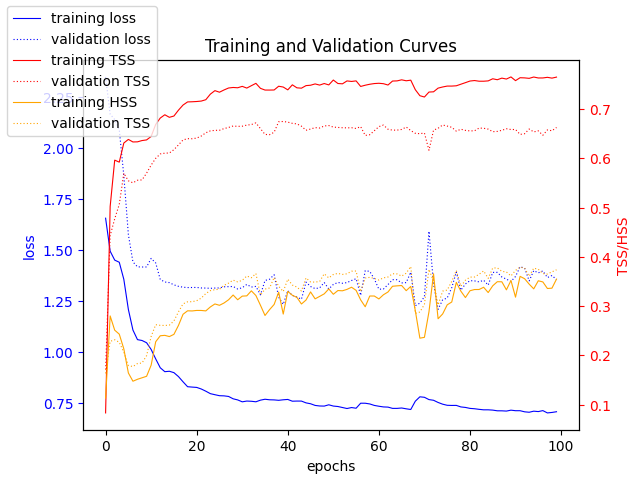

In [12]:
epochs = []
training_loss = []
validation_loss = []
training_tss = []
validation_tss = []
training_hss = []
validation_hss = []

previous_lr = optimizer.param_groups[0]['lr']

# for epoch in range(num_epochs):
for epoch in trange(num_epochs):

    ### training loop
    model.train()
    running_loss = 0.0
    predicted_training_labels = np.array([])
    y_train = np.array([])
    
#     for data, target in tqdm(dataloader):
    for data, target in dataloader:
        
        data = data.to(device)
        target = target.to(device)
        
        optimizer.zero_grad()
        output = model(data)
        output.to(device)
        loss = criterion(output, target.float())
        loss.backward()
        optimizer.step()
        
        if scheduler_type == 'cos':
            scheduler.step()
            
        running_loss += loss.item()
        with torch.no_grad(): predicted_training_labels = np.append(predicted_training_labels, output.cpu())
        with torch.no_grad(): y_train = np.append(y_train, target.cpu())

    predicted_training_labels = np.where(predicted_training_labels > 0.1, 1, 0)

    train_loss = running_loss / len(dataloader)
    # cm = confusion_matrix_plots(y_train.astype(int), predicted_training_labels.astype(int))
    # TN,FP,TP,FN = cm.confusion_table()
    # train_TSS = (TP/(TP+FN) - FP/(FP+TN))
    train_tss = true_skill_score(y_train.astype(int), predicted_training_labels.astype(int))
    train_hss = heidke_skill_score(y_train.astype(int), predicted_training_labels.astype(int))

    ### validation loop
    model.eval()
    with torch.no_grad():
        running_loss = 0.0
        predicted_val_labels = np.array([])
        y_val = np.array([])

#         for batch_data, labels in tqdm(val_dataloader):
        for batch_data, labels in val_dataloader:
        
            batch_data = batch_data.to(device)
            labels = labels.to(device)
            
            outputs = model(batch_data)
            outputs.to(device)
            loss = criterion(outputs, labels.float())
            running_loss += loss.item()
            predicted_val_labels = np.append(predicted_val_labels, outputs.cpu())
            y_val = np.append(y_val, labels.cpu())
            
    predicted_val_labels = np.where(predicted_val_labels > 0.1, 1, 0)

    val_loss = running_loss / len(val_dataloader)
    val_tss = true_skill_score(y_val.astype(int), predicted_val_labels.astype(int))
    val_hss = heidke_skill_score(y_val.astype(int), predicted_val_labels.astype(int))

    epochs.append(epoch)
    training_loss.append(train_loss)
    validation_loss.append(val_loss)
    training_tss.append(train_tss)
    validation_tss.append(val_tss)
    training_hss.append(train_hss)
    validation_hss.append(val_hss)
    
    if scheduler_type == 'plat':
        if metric == 'tss':
            scheduler.step(val_tss) # when tuning for tss
        elif metric == 'hss':
            scheduler.step(val_hss) # when tuning for hss
            
        current_lr = scheduler.get_last_lr()[0]
        if current_lr < previous_lr:
            print(f"Learning rate reduced to: {current_lr}")
        previous_lr = current_lr
    

print(f"final train tss = {training_tss[-1]:.4f} : final val tss = {validation_tss[-1]:.4f}")
print(f"final train hss = {training_hss[-1]:.4f} : final val hss = {validation_hss[-1]:.4f}")
# plot_training_validation_curves(training_tss, validation_tss, training_loss, validation_loss, num_epochs)
plot_training_validation_curves(training_hss, validation_hss, training_tss, validation_tss, training_loss, validation_loss, num_epochs)


100%|██████████| 379/379 [00:01<00:00, 259.19it/s]



test_TSS: 0.5378

test_HSS: 0.1877

length of predicted_test_labels: 4365810
Value: 0, Count: 3732513 perc: 0.8549416946683434
Value: 1, Count: 633297 perc: 0.14505830533165667


Confusion matrix, without normalization
[[3687847  544097]
 [  44666   89200]]


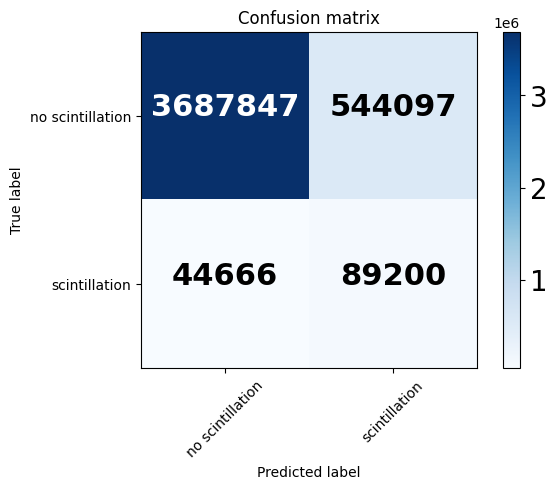

Normalized confusion matrix
[[0.87143095 0.12856905]
 [0.33366202 0.66633798]]


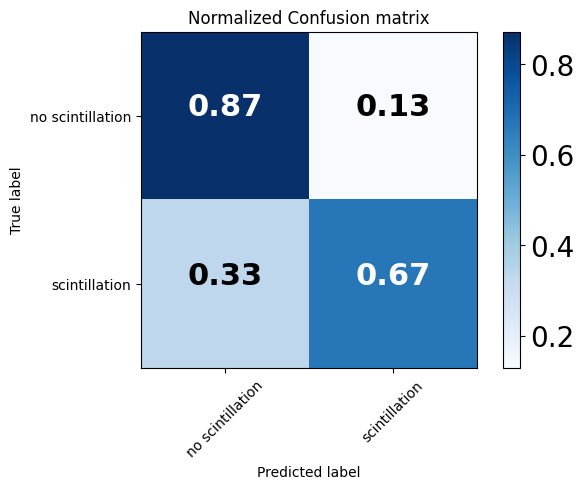

In [13]:
### test loop
predicted_test_labels = np.array([])

model.eval()
with torch.no_grad():
    for batch_data, labels in tqdm(test_dataloader):        
        batch_data = batch_data.to(device)
        labels.to(device)
        outputs = model(batch_data)
        predicted_test_labels = np.append(predicted_test_labels, outputs.cpu())

predicted_test_labels = np.where(predicted_test_labels > 0.1, 1, 0)

y_test_truncated = test_labels.squeeze().flatten().cpu().numpy()

cm = confusion_matrix_plots(y_test_truncated.astype(int), predicted_test_labels.astype(int))
TN,FP,TP,FN = cm.confusion_table()
# test_TSS = (TP/(TP+FN) - FP/(FP+TN))
test_tss = true_skill_score(y_test_truncated.astype(int), predicted_test_labels.astype(int))
test_hss = heidke_skill_score(y_test_truncated.astype(int), predicted_test_labels.astype(int))

print(end='\n')
# print(f"test_TSS: {test_TSS:.4f}", end='\n\n')
print(f"test_TSS: {test_tss:.4f}", end='\n\n')
print(f"test_HSS: {test_hss:.4f}", end='\n\n')

unique_values, counts = np.unique(predicted_test_labels, return_counts=True)
print("length of predicted_test_labels: {}".format(len(predicted_test_labels)))
for val, count in zip(unique_values, counts):
    perc = count/(len(predicted_test_labels))
    print(f"Value: {val}, Count: {count} perc: {perc}")

print(end='\n\n')

AUC_PRC = (average_precision_score(y_test_truncated,predicted_test_labels))
precision = ( TP/(TP+FP) )
recall = ( TP/(TP+FN) )
specificity = ( TN/(TN+FP) )
F1 = ( 2*((precision*recall)/(precision+recall)) )

cm_sklearn = confusion_matrix(y_test_truncated, predicted_test_labels)
confusion_matrix_class_names = ['no scintillation','scintillation']

fig1 = plt.figure()
cm.plot_confusion_matrix(cm_sklearn, classes=confusion_matrix_class_names, normalize=False, title='Confusion matrix')
plt.show()

fig2 = plt.figure()
cm.plot_confusion_matrix(cm_sklearn, classes=confusion_matrix_class_names, normalize=True, title='Normalized Confusion matrix')
plt.show()

In [14]:
processed_data_2016 = pd.read_csv("processed_data_2016.csv")
processed_data_2016 = processed_data_2016.drop(processed_data_2016.columns[0], axis=1)
predicted_label = 'sigmaPhi projected to vertical at prediction time [radians]'
y_2016 = processed_data_2016[predicted_label].values
print(y_2016.shape)

X_2016_fSelect = processed_data_2016.drop(predicted_label, axis=1)
X_2016_fSelect = X_2016_fSelect.values
print(X_2016_fSelect.shape)

X_scaled_2016 = scaler_X.transform(X_2016_fSelect)

X_scaled_2016 = reshape_data_to_seq_length(X_scaled_2016, seq_length)
test_labels_2016 = reshape_labels_to_seq_length(y_2016, seq_length)

test_data_2016 = torch.tensor(X_scaled_2016, dtype=torch.float32)
test_data_2016 = test_data_2016.to(device)
test_labels_2016 = test_labels_2016.to(device)
test_dataset_2016 = TensorDataset(test_data_2016, test_labels_2016)
test_dataloader_2016 = DataLoader(test_dataset_2016, batch_size=batch_size, shuffle=False, worker_init_fn=seed_worker)


(126426,)
(126426, 15)


100%|██████████| 11/11 [00:00<00:00, 765.36it/s]


test_TSS_2016: 0.4645

test_HSS_2016: 0.1950

length of predicted_test_labels_2016: 126405
Value: 0, Count: 110139 perc: 0.8713183813931411
Value: 1, Count: 16266 perc: 0.1286816186068589


Confusion matrix, without normalization
[[108312  13771]
 [  1827   2495]]


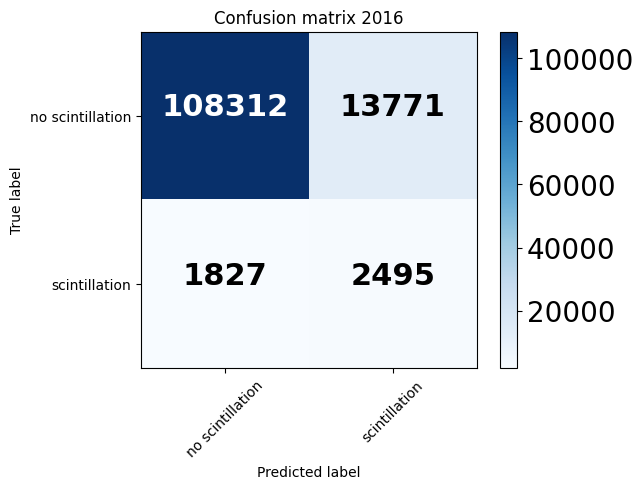

Normalized confusion matrix
[[0.88719969 0.11280031]
 [0.42272096 0.57727904]]


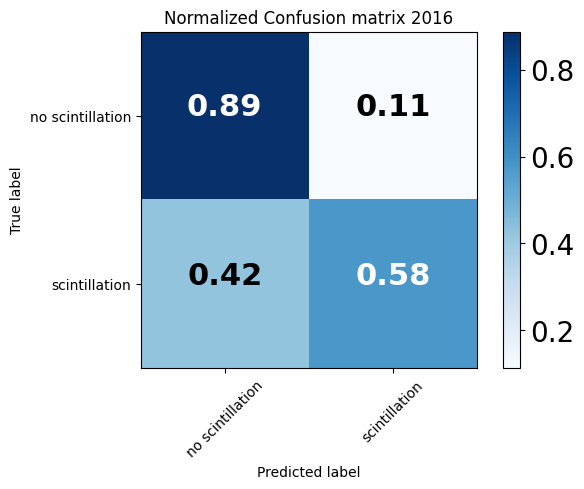

In [15]:
### test loop 2016
predicted_test_labels_2016 = np.array([])

model.eval()
with torch.no_grad():
    for batch_data, labels in tqdm(test_dataloader_2016):
        batch_data = batch_data.to(device)
        labels = labels.to(device)
        outputs = model(batch_data)
        predicted_test_labels_2016 = np.append(predicted_test_labels_2016, outputs.cpu())

predicted_test_labels_2016 = np.where(predicted_test_labels_2016 > 0.1, 1, 0)

y_2016_truncated = test_labels_2016.squeeze().flatten().cpu().numpy()

cm = confusion_matrix_plots(y_2016_truncated.astype(int), predicted_test_labels_2016.astype(int))
TN,FP,TP,FN = cm.confusion_table()
test_tss_2016 = (TP/(TP+FN) - FP/(FP+TN))
test_hss_2016 = heidke_skill_score(y_2016_truncated.astype(int), predicted_test_labels_2016.astype(int))

print(end='\n')
print(f"test_TSS_2016: {test_tss_2016:.4f}", end='\n\n')
print(f"test_HSS_2016: {test_hss_2016:.4f}", end='\n\n')

unique_values, counts = np.unique(predicted_test_labels_2016, return_counts=True)
print("length of predicted_test_labels_2016: {}".format(len(predicted_test_labels_2016)))
for val, count in zip(unique_values, counts):
    perc = count/(len(predicted_test_labels_2016))
    print(f"Value: {val}, Count: {count} perc: {perc}")

print(end='\n\n')

AUC_PRC = (average_precision_score(y_2016_truncated,predicted_test_labels_2016))
precision = ( TP/(TP+FP) )
recall = ( TP/(TP+FN) )
specificity = ( TN/(TN+FP) )
F1 = ( 2*((precision*recall)/(precision+recall)) )

cm_sklearn = confusion_matrix(y_2016_truncated, predicted_test_labels_2016)
confusion_matrix_class_names = ['no scintillation','scintillation']

fig1 = plt.figure()
cm.plot_confusion_matrix(cm_sklearn, classes=confusion_matrix_class_names, normalize=False, title='Confusion matrix 2016')
plt.show()

fig2 = plt.figure()
cm.plot_confusion_matrix(cm_sklearn, classes=confusion_matrix_class_names, normalize=True, title='Normalized Confusion matrix 2016')
plt.show()

In [16]:
### test loop 2016
predicted_test_labels_2016 = np.array([])

model.eval()
with torch.no_grad():
    for batch_data, labels in tqdm(test_dataloader_2016):
        batch_data = batch_data.to(device)
        labels = labels.to(device)
        outputs = model(batch_data)
        predicted_test_labels_2016 = np.append(predicted_test_labels_2016, outputs.cpu())

predicted_test_probs_2016 = predicted_test_labels_2016.copy()
y_2016_truncated = test_labels_2016.squeeze().flatten().cpu().numpy()

# predicted_probabilities_2016 = model.predict_proba(X_test)[:, 1]  # Select probabilities for the positive class

from sklearn.metrics import roc_auc_score
# auc = roc_auc_score(y_2016_truncated, predicted_probabilities_2016)
auc = roc_auc_score(y_2016_truncated, predicted_test_probs_2016)

print(f"AUC-ROC: {auc:.2}")
from sklearn.metrics import precision_recall_curve, auc
precision, recall, _ = precision_recall_curve(y_2016_truncated, predicted_test_probs_2016)
pr_auc = auc(recall, precision)
print(f"Precision-Recall AUC: {pr_auc:.2}")


100%|██████████| 11/11 [00:00<00:00, 795.25it/s]

AUC-ROC: 0.85
Precision-Recall AUC: 0.18
